In [1]:
import sys
sys.path.append('../src/')

from pdb2mrc import PDB2MRC
from plotting_tools import *
import torch

%load_ext autoreload
%autoreload 2

In [2]:
fftn = lambda array: torch.fft.fftshift(torch.fft.fftn(torch.fft.ifftshift(array)))
ifftn = lambda array: torch.fft.fftshift(torch.fft.ifftn(torch.fft.ifftshift(array)))

## Instantiate class

In [3]:
pdb_code = '7a4m'
pm = PDB2MRC(pdb_code)

## Download PDB file

In [4]:
pm.fetch_pdb()

./pdb-data/7a4m
PDB file saved to: ./pdb-data/7a4m.cif


## Compute particle potential

In [5]:
pm.build_particle(n=256, dx=1)

100%|█████████████████████████████████████████████| 7/7 [00:04<00:00,  1.61it/s]


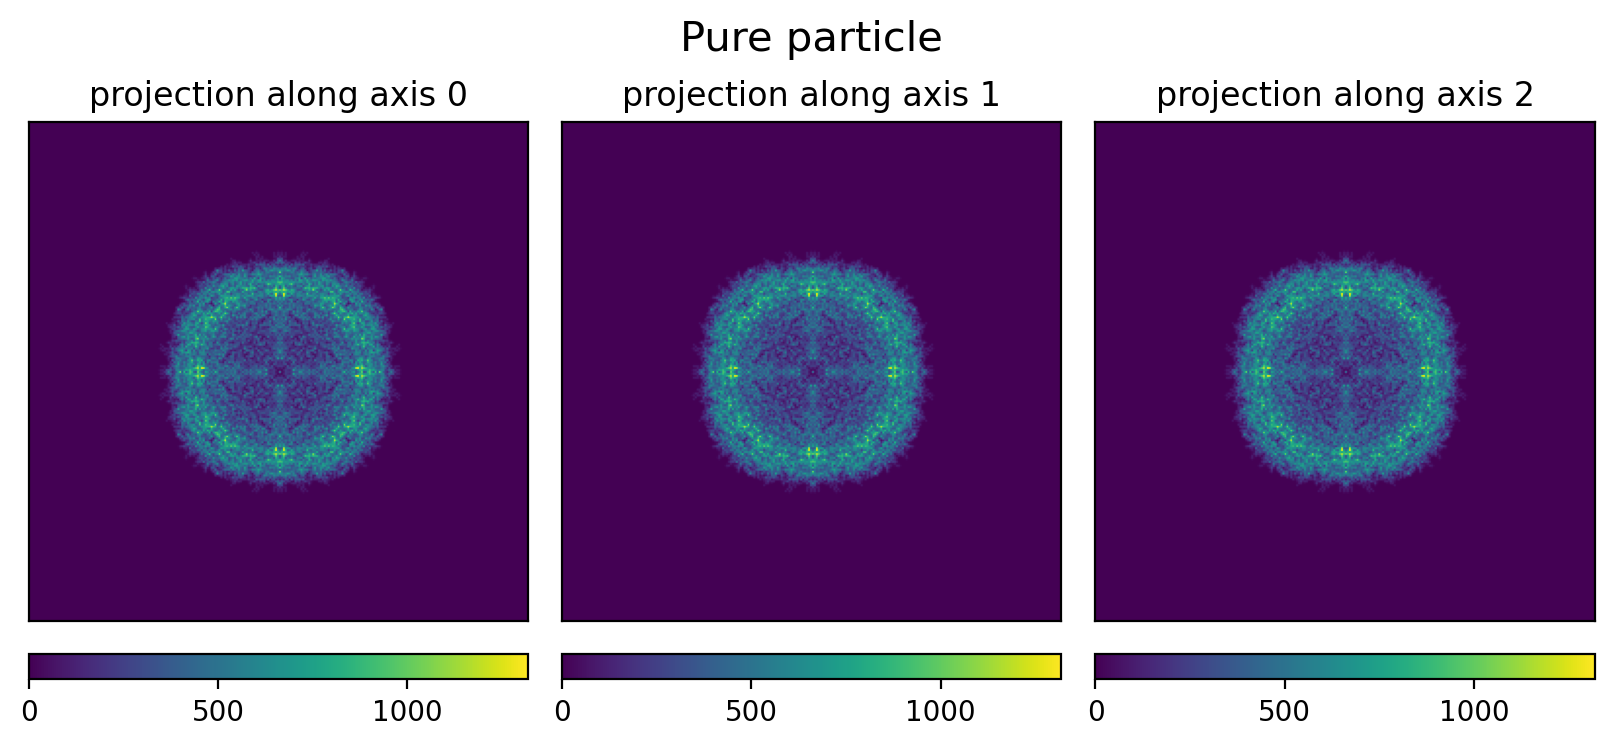

In [6]:
plot3d(pm.particle, title='Pure particle')

## Solvate
Note: Time taken increases exponentially with larger box sizes.
- 256A x 256A x 256A takes 1.5 hours.
- 150A x 150A x 150A takes 3 minutes.
- 100A x 100A x 100A takes 20 seconds.

In [ ]:
pm.solvate()

  0%|                                                     | 0/5 [00:00<?, ?it/s]

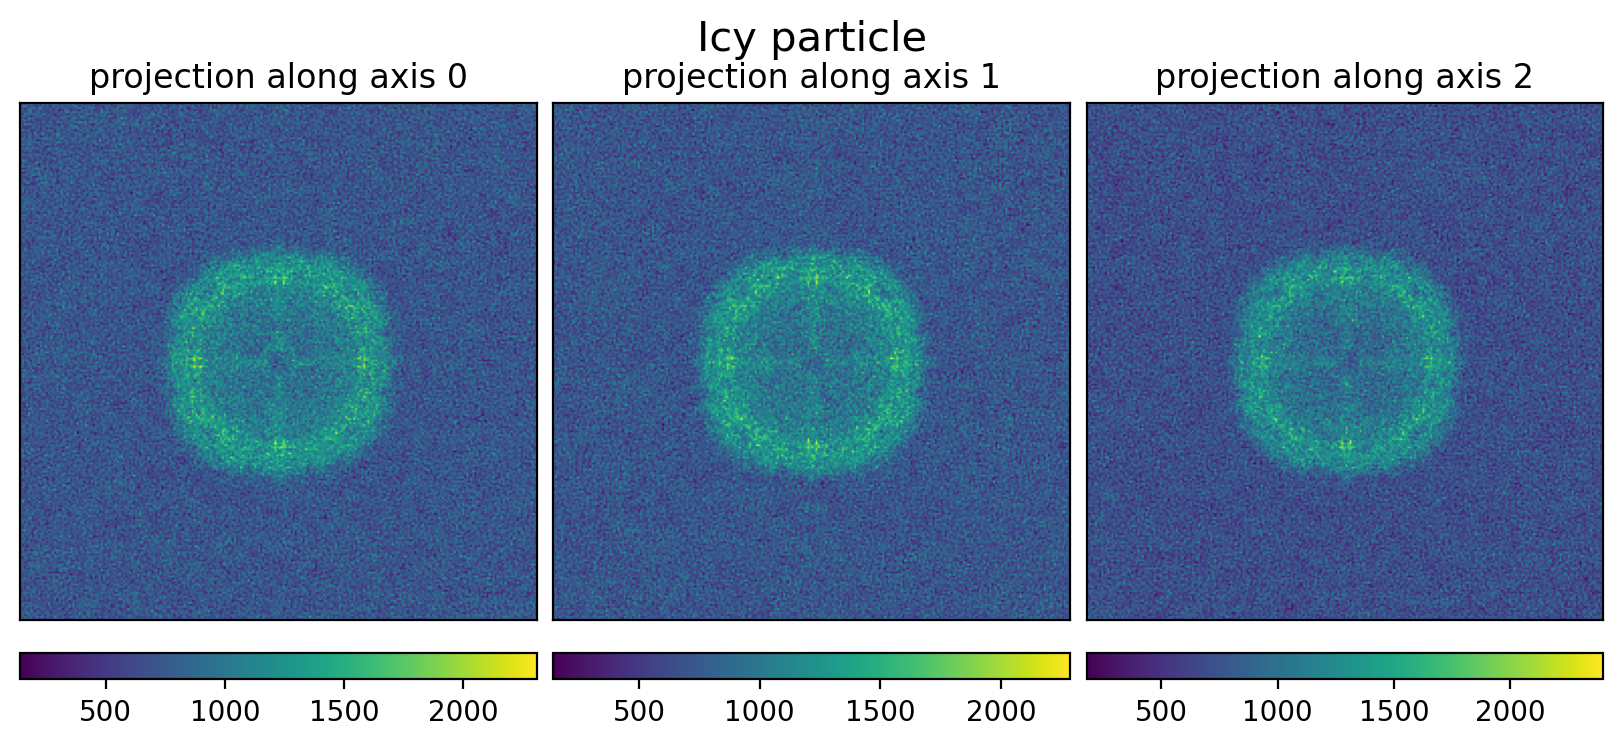

In [10]:
plot3d(pm.icy_particle, title='Icy particle')

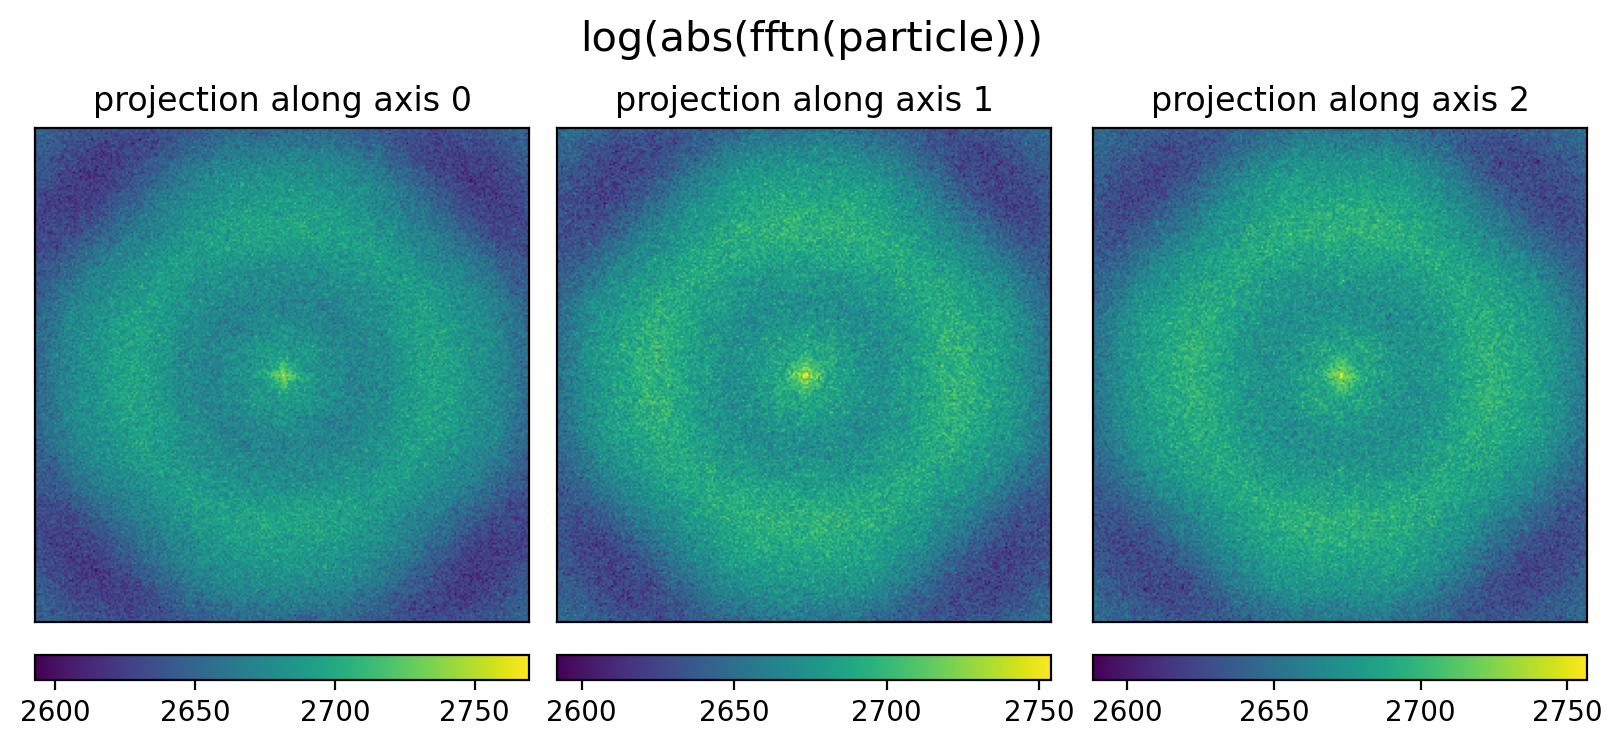

In [11]:
plot3d(torch.log(torch.abs(fftn(pm.icy_particle))), title='log(abs(fftn(particle)))')

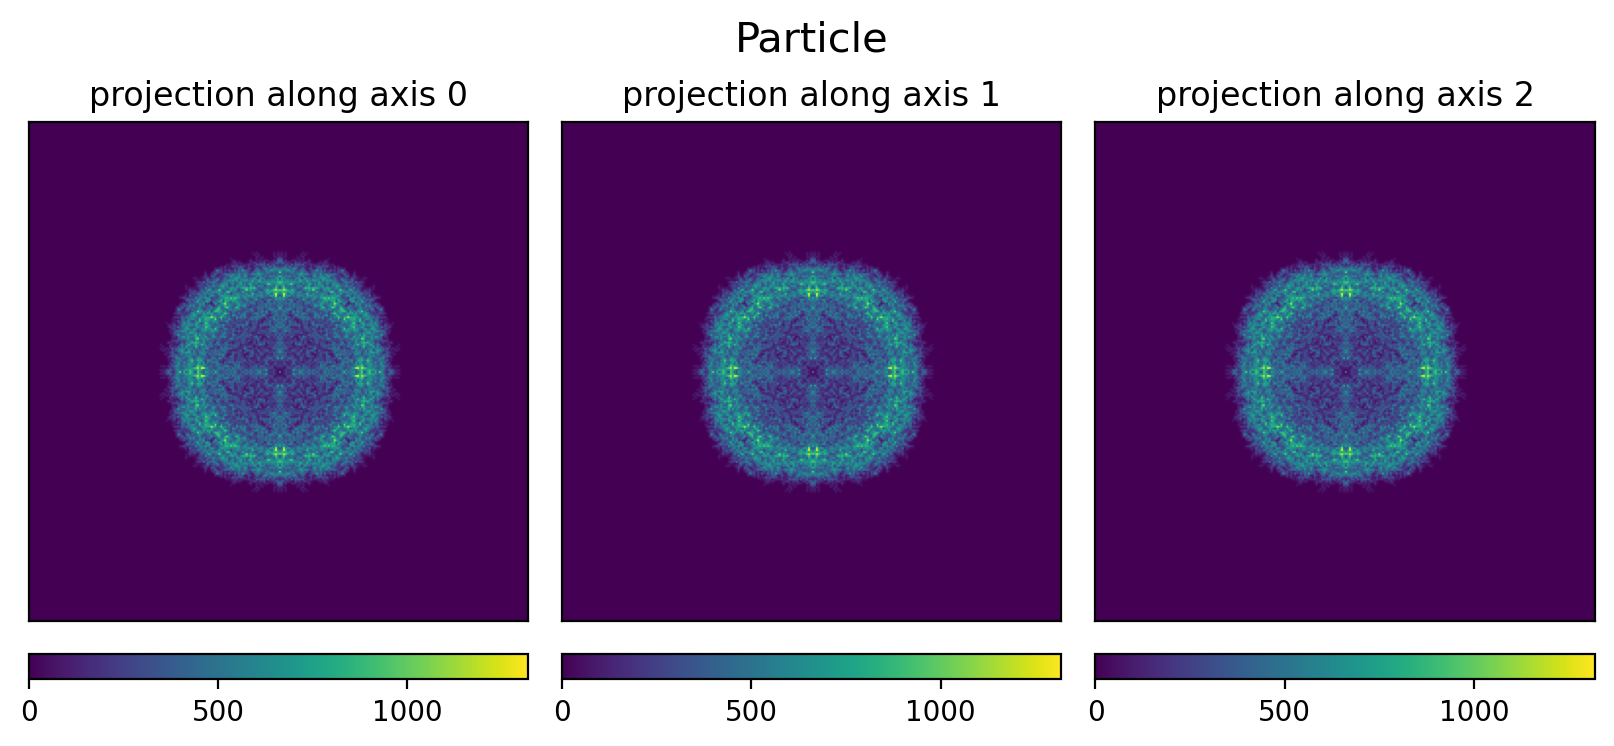

In [18]:
plot3d(pm.particle, title='Particle')

In [23]:
len(pm.atomic_potentials)

8

In [29]:
torch.save(pm.atomic_potentials['C'], save_folder + 'atomic_potential_C.pt')

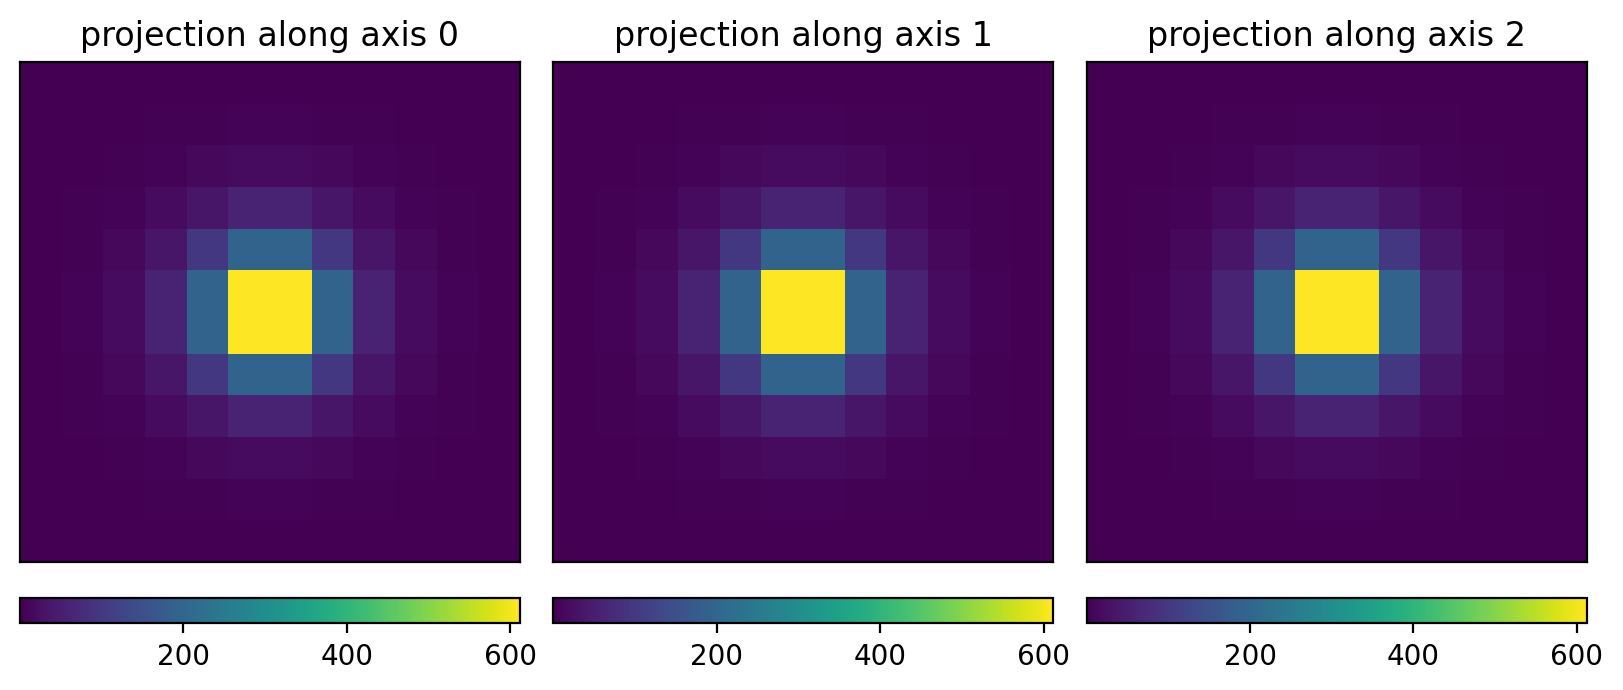

In [22]:
plot3d(pm.atomic_potentials['O'])